# Predictive Text Generation using LSTM

To perform text generation using RNN, we need to show the model various examples to make a better prediction character by character. For this task, we will be using the Project Gutenberg's The Adventures of Sherlock Holmes, by Arthur Conan Doyle available as a .txt file.

[Sherlock Holmes Text File](SherlockHolmes.txt)

## Installing Packages

In [1]:
%pip install keras random numpy matplotlib

ERROR: Could not find a version that satisfies the requirement random (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python -m pip install --upgrade pip
ERROR: No matching distribution found for random
Note: you may need to restart the kernel to use updated packages.


## Importing libraries

In [2]:
%pip install keras --upgrade

from keras.models import Sequential
from keras.layers import Dense, Activation, LSTM, Dropout
from keras.optimizers import RMSprop
from keras.utils import get_file
import keras
import random
import numpy as np
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


2025-06-16 21:38:51.507594: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-16 21:38:51.511029: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-16 21:38:51.520043: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750109931.534571    1803 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750109931.538980    1803 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750109931.551528    1803 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

## Reading & Preprocessing

In [3]:
# Reading the data
text = open('SherlockHolmes.txt').read().lower()
print('Given script has ' + str(len(text)) + ' characters')

# Stripping because data is too long

text = text[1302:]
for ch in ['0','1', '2', '3', '4', '5', '6', '7', '8', '9', '!', '"', '$', '%', '&', '~', '`', '(', ')', '*',
          '-', '/', ';', '@', '?', ':', '©', '¢', 'ã', '\xa0', '\n', '\r', '.']:
       if ch in text:
             text=text.replace(ch,' ')
print(set(text))     


Given script has 581862 characters
{'u', 'w', 'c', 'p', 'g', "'", 'q', 'o', 't', 'y', 'd', 'a', 'e', 'x', 'k', 'f', 'j', 'n', 'v', 'b', 'i', 'h', 'm', 'z', 'r', 's', ' ', 'l', ',', '�'}


## Creating sliding window function

Now, we can create a sliding window function in which all the characters inside the window are treated as input and the following character is treated as output. We use the window size of 50 and step size as 3.

In [4]:
def window_transform(text, window_size, step_size):    
    inputs = []
    outputs = []
    
    n_batches = int((len(text)-window_size) / step_size)    
    
    for i in range(n_batches-1):
        a = text[i * step_size:((i * step_size) + window_size)]
        inputs.append(a)
        b = text[(i * step_size) + window_size]
        outputs.append(b)
    return inputs,outputs
# Calling the window function
window_size = 50
step_size = 3
inputs, outputs = window_transform(text, window_size, step_size)

## Results

In [5]:
inputs[502], outputs[502]

('caine and ambition, the drowsiness of the drug, an', 'd')

In [6]:
inputs[503], outputs[503]

('ne and ambition, the drowsiness of the drug, and t', 'h')

Now, let us try to formulate the problem in the context of machine learning. Above we saw the output of set(text) resulted in 33 unique characters, therefore, the given problem formulates in the multi-class classification problem.

To begin with, we first sort the output of set(text) and map them to a unique numerical value.

In [7]:
# Sorting the unique elements
chars = sorted(list(set(text)))
# Encoding 
chars_to_indices = dict((c, i) for i, c in enumerate(chars))
# Decoding
indices_to_chars = dict((i, c) for i, c in enumerate(chars))


## Transformation

For instance, chars_to_indices['r'] results in 20 which defines that character r is mapped to value 20.

Now, we have each character mapped to a numeric value, it is time to transform the input/output vector in the same numeric format:

In [8]:
def encode_io_pairs(text, window_size, step_size):    
    num_chars = len(chars)
    
    # cut up text into character input/output pairs
    inputs, outputs = window_transform(text, window_size, step_size)
    
    # create empty vessels for one-hot encoded input/output
    X = np.zeros((len(inputs), window_size, num_chars), dtype=np.bool)
    y = np.zeros((len(inputs), num_chars), dtype=np.bool)
    
    # loop over inputs/outputs and tranform and store in X/y
    for i, sentence in enumerate(inputs):
        for t, char in enumerate(sentence):
            X[i, t, chars_to_indices[char]] = 1
        y[i, chars_to_indices[outputs[i]]] = 1
        
    return X,y
X, y = encode_io_pairs(text, window_size, step_size)


## Building the LSTM network

Starting with the first layer having 120 nodes followed by a fully-connected linear layer and a softmax layer.

In [9]:
# Designing the model
model = Sequential()
model.add(LSTM(120, input_shape=(window_size, len(chars))))
model.add(Dropout(0.22))
model.add(Dense(len(chars), activation='linear'))
model.add(Dense(y.shape[1], activation='softmax'))
# Compiling the model
model.compile(loss='categorical_crossentropy', optimizer='adam')
# Subsetting data for an example
Xsmall = X[:20000,:,:]
ysmall = y[:20000,:]
# Model training
model.fit(Xsmall, ysmall, batch_size=500, epochs=10)

Epoch 1/10


2025-06-16 21:38:56.885824: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-06-16 21:38:57.018442: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 30000000 exceeds 10% of free system memory.


40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 179ms/step - loss: 3.1866
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 176ms/step - loss: 2.8519
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 177ms/step - loss: 2.7954
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 178ms/step - loss: 2.7375
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 177ms/step - loss: 2.6591
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 178ms/step - loss: 2.5466
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 178ms/step - loss: 2.4697
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 176ms/step - loss: 2.4202
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 209ms/step - loss: 2.3790
Epoch 10/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 228ms/step - loss: 2.3407


To proceed with the prediction, we need to follow a simple rule of thumb. We know that at a time, our script accepts a window size of 50 and takes the output as the 51st character. Following this rule, we need to predict a character, later remove the first character from our previous window and add the newly predicted character at the end making it still a window of size 50 then predict the second character and keep following the process.

This method along with the number of characters to be predicted is coded below:

In [10]:
def predict_next_chars(model, input_chars, num_to_predict):     
    pred_chars = ''
    for i in range(num_to_predict):
        # Converting this round's predicted characters to numerical input    
        x_test = np.zeros((1, window_size, len(chars)))
        for t, char in enumerate(input_chars):
            x_test[0, t, chars_to_indices[char]] = 1.
        # make this round's prediction
        test_predict = model.predict(x_test,verbose = 0)[0]
        # translate numerical prediction back to characters
        r = np.argmax(test_predict)                           
        d = indices_to_chars[r] 
        # update predicted_chars and input
        pred_chars+=d
        input_chars+=d
        input_chars = input_chars[1:]
    return pred_chars

Now, all you're left with is the prediction of the new characters which can be performed as shown:

In [11]:
# Prediction
start = 89
num_to_predict = 10
input_chars = text[start: start + window_size]
print('Complete sequence:', text[start:start + window_size + num_to_predict])
print('Input sequence:', input_chars)
print('Output sequence:', predict_next_chars(model, input_chars, num_to_predict = num_to_predict))

Complete sequence: otion akin to love for irene adler  all emotions, and that o
Input sequence: otion akin to love for irene adler  all emotions, 
Output sequence: an  he the


## Plot training

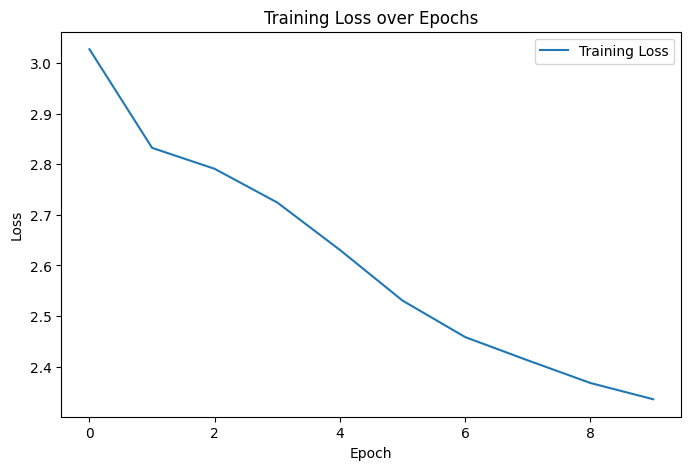

In [12]:
# Retrieve loss history from the model training
history = model.history.history

plt.figure(figsize=(8, 5))
plt.plot(history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.show()